# Imports

In [11]:
import pandas as pd
from qqman import qqman
import matplotlib.pyplot as plt

# %pip install pandas qqman

# Plink GWAS Manhattan and QQ Plot

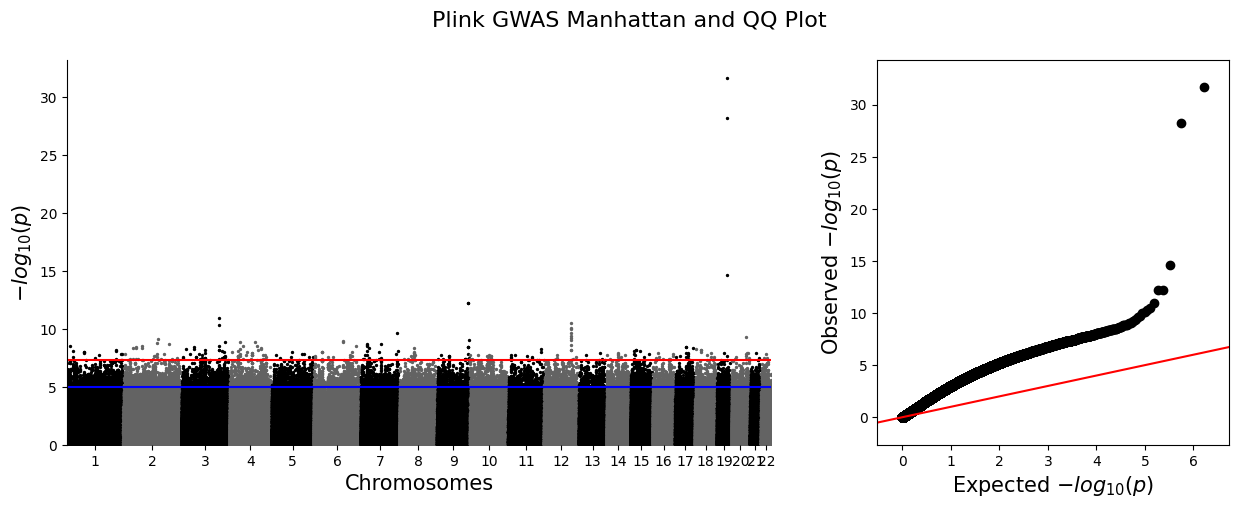

In [18]:
plink = pd.read_csv("data/ps3_gwas.assoc.linear", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("Plink GWAS Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(plink, ax=ax0)
qqman.qqplot(plink, ax=ax1)

# GWAS in Python Manhattan and QQ Plot

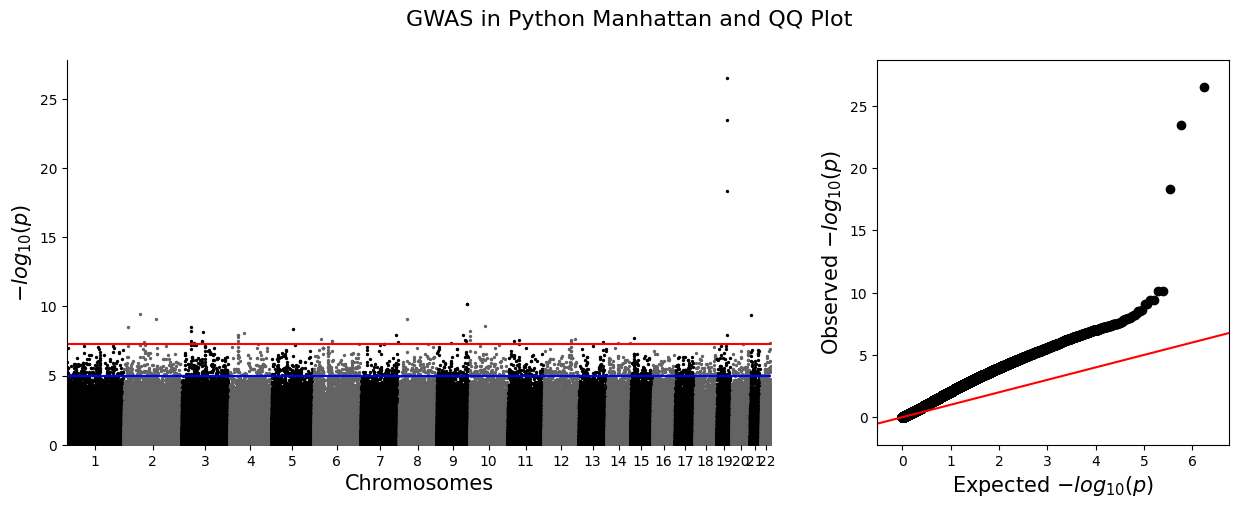

In [19]:
gwas_py = pd.read_csv("gwas_results.tsv", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("GWAS in Python Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(gwas_py, ax=ax0)
qqman.qqplot(gwas_py, ax=ax1)

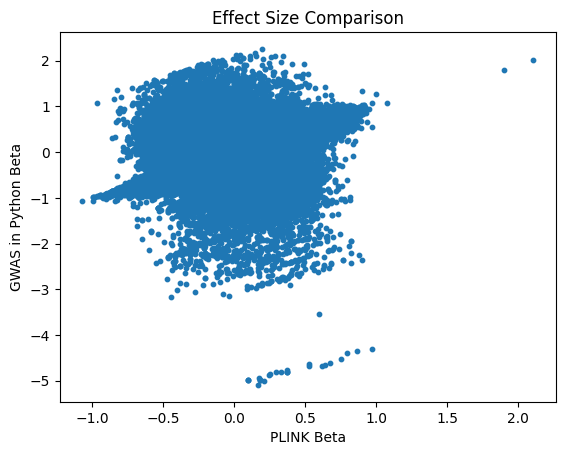

In [22]:
merged = plink.merge(gwas_py, on="SNP", suffixes=("_plink", "_gwas_py"))
merged[["BETA_plink", "BETA_gwas_py"]].corr()
import matplotlib.pyplot as plt

plt.scatter(merged["BETA_plink"], merged["BETA_gwas_py"], s=10)
plt.xlabel("PLINK Beta")
plt.ylabel("GWAS in Python Beta")
plt.title("Effect Size Comparison")
plt.show()

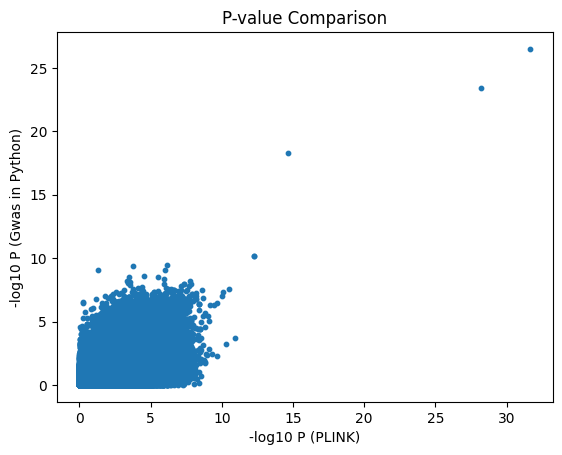

In [23]:
import numpy as np

merged["logP_plink"] = -np.log10(merged["P_plink"])
merged["logP_gwas_py"]  = -np.log10(merged["P_gwas_py"])

plt.scatter(merged["logP_plink"], merged["logP_gwas_py"], s=10)
plt.xlabel("-log10 P (PLINK)")
plt.ylabel("-log10 P (Gwas in Python)")
plt.title("P-value Comparison")
plt.show()

In [24]:
merged["rank_plink"] = merged["P_plink"].rank(method="min")
merged["rank_gwas_py"]  = merged["P_gwas_py"].rank(method="min")

merged[["rank_plink", "rank_gwas_py"]].corr()

top_plink = set(plink.nsmallest(10, "P")["SNP"])
top_gwas_py  = set(gwas_py.nsmallest(10, "P")["SNP"])

print("Overlap in Top 10:", len(top_plink & top_gwas_py))

Overlap in Top 10: 5


In [25]:
summary = merged[[
    "SNP",
    "BETA_plink", "BETA_gwas_py",
    "P_plink", "P_gwas_py",
    "rank_plink", "rank_gwas_py"
]].sort_values("rank_plink").head(20)

summary

,SNP,BETA_plink,BETA_gwas_py,P_plink,P_gwas_py,rank_plink,rank_gwas_py
301222,rs62117204,2.1050,2.018280,2.122000e-32,3.112399e-27,1.0,1.0
301225,rs4803750,1.8980,1.789413,6.102000e-29,3.474536e-24,2.0,2.0
301221,rs1531517,1.0010,1.278415,2.328000e-15,4.902376e-19,3.0,3.0
830779,rs2519093,-0.9908,-0.992347,5.676000e-13,6.913235e-11,4.0,4.0
830781,rs507666,-0.9908,-0.992347,5.676000e-13,6.913235e-11,4.0,4.0
535241,rs358702,-0.5654,0.578500,1.204000e-11,2.145549e-04,6.0,12896.0
120251,rs11113551,-0.7108,-0.869567,3.291000e-11,2.690524e-08,7.0,29.0
535248,rs7636224,-0.5419,0.568154,4.915000e-11,5.400738e-04,8.0,21413.0
120240,rs2374725,-0.7102,-0.860164,8.035000e-11,4.603422e-08,9.0,47.0
120242,rs11113515,-0.6867,-0.857292,1.027000e-10,9.026889e-08,10.0,79.0


In [26]:
merged["BETA_plink"].corr(merged["BETA_gwas_py"])

np.float64(0.501425538910008)